<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 2 — Clasificación con k-NN y Naive Bayes</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporciona el dataset **Pima Indians Diabetes** (NIDDK, 1988), un clásico benchmark biomédico que contiene registros de **768 mujeres** con variables metabólicas y demográficas. La variable objetivo es `Outcome` (0 = no diabética, 1 = diabética con diabetes mellitus tipo 2).

Tu misión: construir, evaluar y comparar un clasificador **k-NN** y un **Naive Bayes Gaussiano** para predecir diabetes a partir de variables clínicas. Para cada decisión de diseño deberás **justificar clínicamente** tu elección.

---
> **Dataset:** `diabetes.csv`  
> **Fuente:** Smith, J.W. et al. (1988). *Using the ADAP Learning Algorithm to Forecast the Onset of Diabetes Mellitus*. Proceedings of the Annual Symposium on Computer Application in Medical Care.  
> Disponible en: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

---

### Variables del dataset

| Variable | Descripción | Unidad |
|---|---|---|
| Pregnancies | Número de embarazos | — |
| Glucose | Glucosa plasmática en ayunas (OGTT 2h) | mg/dL |
| BloodPressure | Presión arterial diastólica | mmHg |
| SkinThickness | Grosor del pliegue tricipital | mm |
| Insulin | Insulina sérica a las 2h | μU/mL |
| BMI | Índice de masa corporal | kg/m² |
| DiabetesPedigreeFunction | Score hereditario de diabetes | — |
| Age | Edad | años |
| **Outcome** | **Diagnóstico de diabetes** | **0/1** |

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

---
## Ejercicio 1 — Diseño previo al código (conceptual)

> **Antes de escribir una línea de código**, razona sobre el problema.

### 1.1 — ¿k-NN o Naive Bayes? ¿O ambos?

Para este dataset de variables clínicas continuas, responde **antes de ver los datos**:

1. ¿Qué suposición hace Naive Bayes sobre las features? ¿Es razonable para glucosa, IMC y presión arterial? ¿Por qué?
2. k-NN requiere escalar los datos. Si no lo hicieras, ¿qué feature dominaría la distancia euclidiana y por qué? (pista: revisa las unidades de la tabla)
3. Para un sistema de tamizaje masivo (screening) de diabetes en una posta médica, ¿priorizarías **recall** o **precision**? Argumenta clínicamente.
4. Si la prevalencia de diabetes en la población fuera solo 5% (vs ~35% en este dataset), ¿cómo afectaría eso a la interpretación del posterior de Naive Bayes?

**📝 Tu respuesta (edita esta celda):**
1. Supone que son variables independientes, en este caso no es razonable aplicarlo a variables como lo son glucosa, IMC y Presión Arterial puesto que está demostrado que están clínicamente relacionadas.
2. Dominaría la glucosa puesto que se trata de personas con diabetes y en menor medida se vería influencia de la presión arterial. Para glucosa, las unidades son pequeñas (mg/dL) por lo que la característica es numéricamente más grande.
3. Clínicamente es prioritaria la sensibilidad porque dentro del grupo de positivos detectados es prudente reconocer cuantos son realmente positivos. El porcentaje debe ser alto y es importante reconocer que es mejor tratar como positivo a alguien que no tiene la enfermedad que tener un paciente positivo sin tratamiento.
4. El modelo estaría sesgado a clasificar en su gran mayoría los casos como negativos. Esto se explica matemáticamente con una disminución del prior lo cual afecta a la sensibilidad o recall.

### 1.2 — Pipeline completo

Dibuja (en texto o diagrama) el pipeline que vas a implementar, indicando **en qué paso** se hace el train/test split y por qué es importante no cruzar esa frontera.

```
diabetes.csv
    │
    ▼
[ Paso A ] EDA  (Análisis y limpieza)← ¿Qué haces aquí?
    │
    ▼
[ Paso B ] División de datos ← ¿Aquí ya haces el split? Sí ¿Por qué? Para tener bien definido el grupo de entrenamiento y testeo. Separar que parte entrenar previene el leakage de datos e influye en que el modelo no memorice
    │
    ├──────── TRAIN ──────────────────────────────────────────────┐
    │                                                             │
    ▼                                                             │
[ Paso C ] Estimamos media y varianza. También hace el escalamiento ← ¿Qué estimas SOLO con train?        │
    │                                                             │
    ▼                                                             │
[ Paso D ] Ajuste de hiperparámetros  ← Entrenamiento de modelos            
    │                                                             │
    └──────── TEST ── (aplicas lo estimado en C) ─────────────────┘
    │
    ▼
[ Paso E ] Matriz de confusión, recall y accuracy  ← Evaluación final
```

**📝 Tu respuesta (edita esta celda):** completa los `___` del diagrama.

---
## Ejercicio 2 — Setup y carga de datos

In [ ]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Colores UPCH
UPCH_RED  = '#8B0000'
UPCH_BLUE = '#1565C0'
UPCH_GRAY = '#4A4A4A'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

# Ruta del dataset
DATA_PATH = Path('/content/drive/MyDrive/Challenges/Challenge_2') / 'diabetes.csv'

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


### Paso 2.1 — Carga y primera inspección

In [ ]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'\nPrimeras filas:')
df.head()

Shape: (768, 9)

Primeras filas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Tipos de datos y valores nulos
print('Tipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nEstadísticas descriptivas:')
df.describe()

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Estadísticas descriptivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Paso 2.2 — Distribución de clases y desbalance

Distribución de clases:
  No diabética (0): 500 pacientes (0.7%)
  Diabética    (1): 268 pacientes (0.3%)


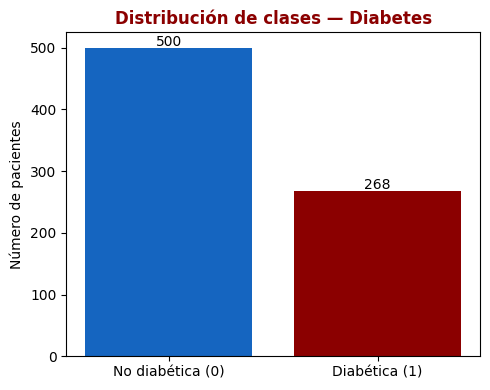

→ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?
Sí, en las clases se observa que predomina la no diabética lo que puede introducir sesgos en el modelo.
 El clasificador trivial sería un Majority Class Classifier y no detectaría nada útil pues su recall sería cero en este caso,
 no serviría en aplicaciones clínicas


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: calcula el conteo y porcentaje de cada clase en 'Outcome'

conteo = df['Outcome'].value_counts()
pct    = conteo/len(df)

print('Distribución de clases:')
print(f'  No diabética (0): {conteo[0]} pacientes ({pct[0]:.1f}%)')
print(f'  Diabética    (1): {conteo[1]} pacientes ({pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))

# TODO 2: grafica las barras con colores [UPCH_BLUE, UPCH_RED]
bars=ax.bar(conteo.index, conteo.values, color=[UPCH_BLUE, UPCH_RED])

ax.set_title('Distribución de clases — Diabetes', fontweight='bold', color=UPCH_RED)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No diabética (0)', 'Diabética (1)'])
ax.set_ylabel('Número de pacientes')

# TODO 3: agrega el valor numérico y porcentaje encima de cada barra
for bar in bars:
    height=bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 3, f'{height}', ha='center')

plt.tight_layout()
plt.savefig('distribucion_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?')

###
print('Sí, en las clases se observa que predomina la no diabética lo que puede introducir sesgos en el modelo.\n El clasificador trivial sería un Majority Class Classifier y no detectaría nada útil pues su recall sería cero en este caso,\n no serviría en aplicaciones clínicas')
####

---
## Ejercicio 3 — Limpieza: valores fisiológicamente imposibles

Este dataset tiene un problema clásico: variables como Glucosa, BloodPressure, BMI e Insulin tienen valores **0** que son fisiológicamente imposibles. Son errores de adquisición codificados como 0 en lugar de `NaN`.

In [ ]:
# Columnas que NO pueden ser 0 fisiológicamente
cols_no_cero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Valores = 0 por columna (antes de limpiar):')
for col in cols_no_cero:
    n_cero = (df[col] == 0).sum()
    print(f'  {col:<25} {n_cero:>4} ({100*n_cero/len(df):.1f}%)')

Valores = 0 por columna (antes de limpiar):
  Glucose                      5 (0.7%)
  BloodPressure               35 (4.6%)
  SkinThickness              227 (29.6%)
  Insulin                    374 (48.7%)
  BMI                         11 (1.4%)


In [ ]:
df_clean = df.copy()

# --- COMPLETA EL CÓDIGO ---
# TODO: reemplaza los valores 0 por NaN en todas las columnas de cols_no_cero
# Pista: usa un loop o df_clean[cols_no_cero].replace()

df_clean[cols_no_cero] = df_clean[cols_no_cero].replace(0,np.nan)

print('Valores NaN tras limpieza:')
print(df_clean[cols_no_cero].isnull().sum())
print('\n→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.')

Valores NaN tras limpieza:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.


---
## Ejercicio 4 — EDA: ¿qué features separan mejor las clases?

Antes de entrenar cualquier modelo, exploramos visualmente qué variables tienen más **poder discriminativo**.

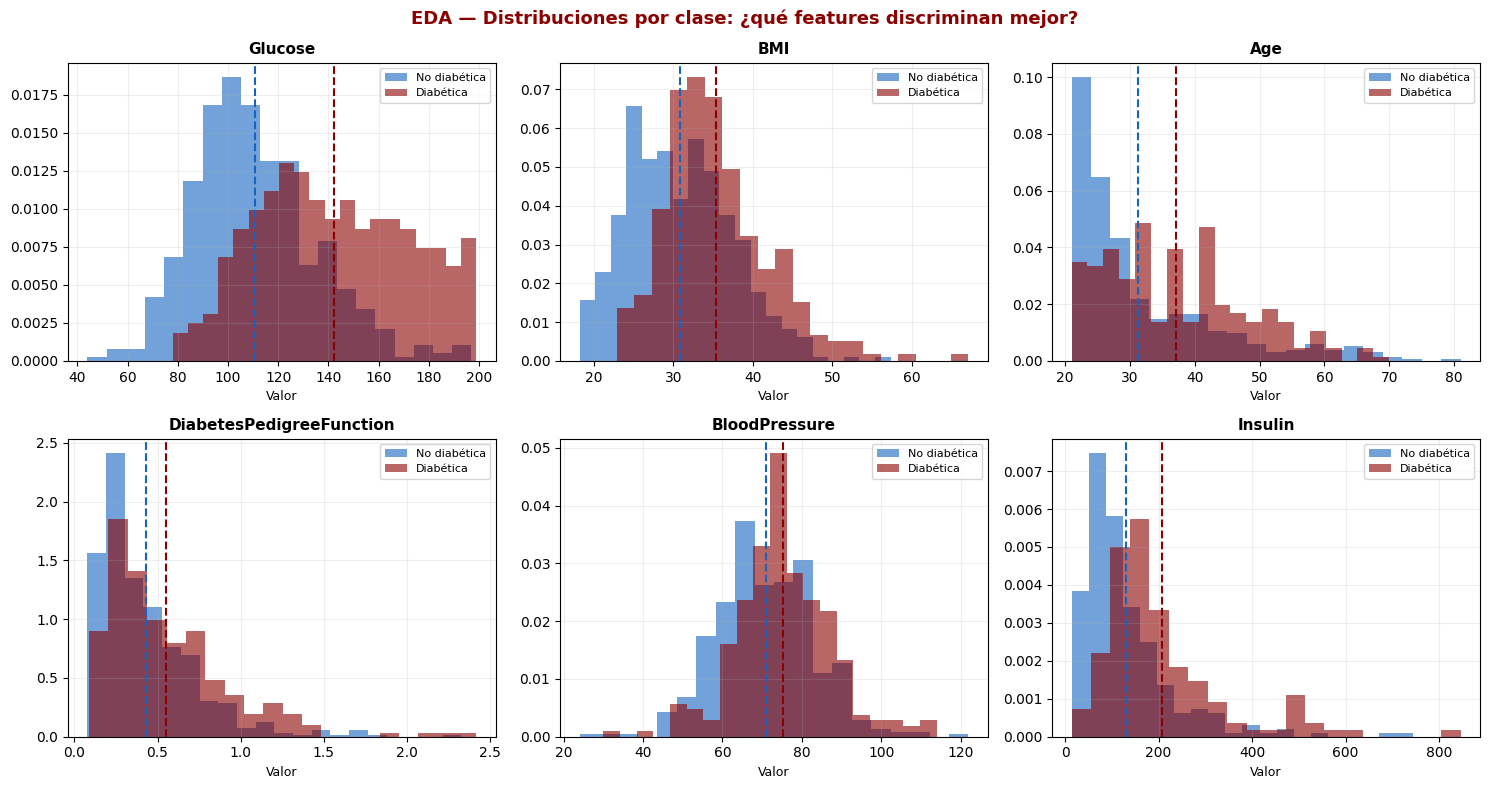

→ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?
La feature con distribuciones más separadas es la glucosa y la que tiene más solapamiento es DiabetesPedigreeFunction


In [ ]:
features_num = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'BloodPressure', 'Insulin']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    ax = axes[i]

    # --- COMPLETA EL CÓDIGO ---
    # TODO: grafica histogramas superpuestos (density=True) para clase 0 y clase 1
    # Usa alpha=0.6, UPCH_BLUE para clase 0, UPCH_RED para clase 1
    # Agrega una línea vertical con la media de cada clase
    for clase, color, label in [(0, UPCH_BLUE, 'No diabética'), (1, UPCH_RED, 'Diabética')]:
        valores = df_clean[df_clean['Outcome'] == clase][feat].dropna()

        # TODO: hist y línea de media (ax.hist, ax.axvline)
        ax.hist(valores, bins=20, density=True, alpha=0.6, color=color, label=label)
        ax.axvline(valores.mean(), color=color, linestyle='--')

    ax.set_title(feat, fontweight='bold', fontsize=11)
    ax.set_xlabel('Valor', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle('EDA — Distribuciones por clase: ¿qué features discriminan mejor?',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?')

####
print('La feature con distribuciones más separadas es la glucosa y la que tiene más solapamiento es DiabetesPedigreeFunction')
####

### Paso 4.2 — Mapa de correlación

Naive Bayes asume independencia condicional. ¿Hay correlaciones fuertes entre features?

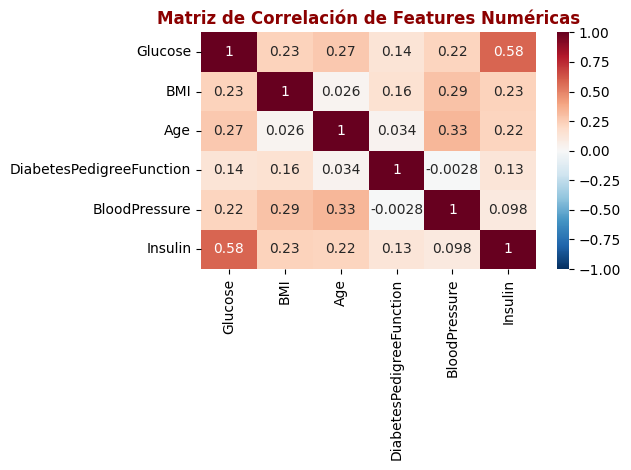

→ Identifica los pares de features con |correlación| > 0.5.
  ¿Viola esto la suposición de Naive Bayes? ¿Cuánto impacto tendrá?
El par de variables con más correlación es glucosa con insulina (0.58), esto sí viola la suposición de independencia entre variables de Naive Bayes 
 Sí influirá pues se asume que las variables no están relacionadas, lo cual quiere decir que no detecta que se está dando la misma información dos veces. 
 Esto traería como consecuencia un sesgo hacia el resultado mayoritario


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: calcula la matriz de correlación de df_clean (solo features numéricas, sin Outcome)
#       y grafícala con seaborn heatmap. Incluye: cmap='RdBu_r', vmin=-1, vmax=1, annot=True

sns.heatmap(df_clean[features_num].corr(), cmap='RdBu_r', vmin=-1, vmax=1, annot=True)

plt.title('Matriz de Correlación de Features Numéricas', fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('correlacion_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('→ Identifica los pares de features con |correlación| > 0.5.')
print('  ¿Viola esto la suposición de Naive Bayes? ¿Cuánto impacto tendrá?')

####
print('El par de variables con más correlación es glucosa con insulina (0.58), esto sí viola la suposición de independencia entre variables de Naive Bayes \n Sí influirá pues se asume que las variables no están relacionadas, lo cual quiere decir que no detecta que se está dando la misma información dos veces. \n Esto traería como consecuencia un sesgo hacia el resultado mayoritario')
####

---
## Ejercicio 5 — Preprocesamiento: split, imputación y escalado

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: separa features (X) y target (y) de df_clean
X = df_clean[features_num].copy()
y = df_clean['Outcome'].values

# TODO 2: haz train_test_split con test_size=0.2, random_state=42, estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}  →  {(y_train==1).sum()} diabéticas ({100*(y_train==1).mean():.1f}%)')
print(f'Test:  {X_test.shape}   →  {(y_test==1).sum()} diabéticas ({100*(y_test==1).mean():.1f}%)')

Train: (614, 6)  →  214 diabéticas (34.9%)
Test:  (154, 6)   →  54 diabéticas (35.1%)


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: imputa los NaN con la MEDIANA de train (no de todo el dataset)
#       Aplica la mediana de train también al test

mediana_train = X_train.median()
X_train_imp   = X_train.copy()
X_test_imp    = X_test.copy()

X_train_imp.fillna(mediana_train, inplace=True)
X_test_imp.fillna(mediana_train, inplace=True)

print(f'NaN en train tras imputación: {np.isnan(X_train_imp).sum()}')
print(f'NaN en test  tras imputación: {np.isnan(X_test_imp).sum()}')

NaN en train tras imputación: Glucose                     0
BMI                         0
Age                         0
DiabetesPedigreeFunction    0
BloodPressure               0
Insulin                     0
dtype: int64
NaN en test  tras imputación: Glucose                     0
BMI                         0
Age                         0
DiabetesPedigreeFunction    0
BloodPressure               0
Insulin                     0
dtype: int64


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: escala con StandardScaler
#       - fit_transform sobre X_train_imp
#       - transform (sin fit) sobre X_test_imp

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.fit_transform(X_test_imp)

print(f'Train escalado — media: {X_train_sc.mean():.4f}  std: {X_train_sc.std():.4f}')

Train escalado — media: 0.0000  std: 1.0000


---
## Ejercicio 6 — Entrenamiento de modelos

### Paso 6.1 — Naive Bayes Gaussiano

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con X_train_imp (NB no necesita escalado, usa datos imputados)
gnb = GaussianNB()
gnb.fit(X_train_imp, y_train)

# TODO 2: predice sobre X_test_imp
y_pred_gnb = gnb.predict(X_test_imp)

# TODO 3: imprime accuracy
acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f'Naive Bayes — Accuracy: {acc_gnb:.4f}')

Naive Bayes — Accuracy: 0.7078


### Paso 6.2 — k-NN: selección de k óptimo

Entrena k-NN para **k = 1, 3, 5, 7, 9, 11, 15** usando validación interna sobre train (80/20). Grafica train vs val accuracy y selecciona k óptimo.

In [ ]:
k_values = [1, 3, 5, 7, 9, 11, 15]
acc_tr_list  = []
acc_val_list = []

# --- COMPLETA EL CÓDIGO ---
# TODO 1: divide X_train_sc / y_train en subconjuntos train_sub / val (80/20, estratificado)
X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(X_train_sc, y_train, test_size=0.2, random_state=42, stratify=y_train)

# TODO 2: itera sobre k_values = [1, 3, 5, 7, 9, 11, 15]
#          guarda acc en train_sub y val para cada k
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn_k.fit(X_tr_sub, y_tr_sub)
    acc_tr_list.append(accuracy_score(y_tr_sub,  knn_k.predict(X_tr_sub)))
    acc_val_list.append(  accuracy_score(y_val, knn_k.predict(X_val)))
    print(f'k={k:>2}  →  train: {acc_tr_list[-1]:.4f}   val: {acc_val_list[-1]:.4f}')

# TODO 3: identifica k óptimo (argmax de acc_val_list)
k_optimo = k_values[np.argmax(acc_val_list)]
print(f'k óptimo = {k_optimo}  (val accuracy = {np.max(acc_val_list):.4f})')

k= 1  →  train: 1.0000   val: 0.7317
k= 3  →  train: 0.8371   val: 0.7317
k= 5  →  train: 0.8065   val: 0.7724
k= 7  →  train: 0.8126   val: 0.7805
k= 9  →  train: 0.8147   val: 0.7805
k=11  →  train: 0.7943   val: 0.7886
k=15  →  train: 0.8106   val: 0.7805
k óptimo = 11  (val accuracy = 0.7886)


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica train vs val accuracy en función de k
# Incluye: línea vertical en k óptimo, leyenda, títulos, colores UPCH


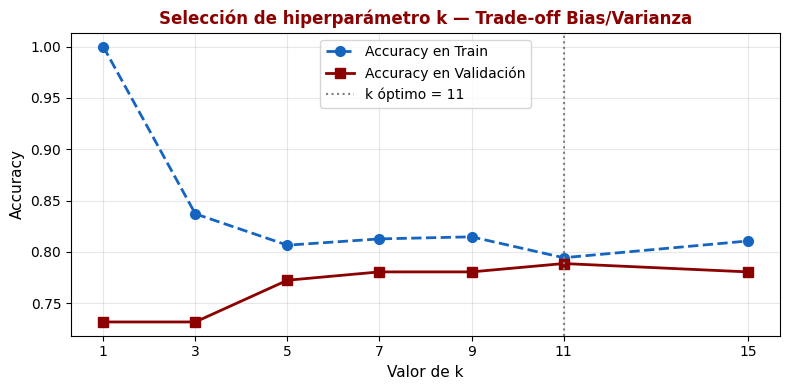

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(k_values, acc_tr_list, 'o--', color=UPCH_BLUE, linewidth=2,
        markersize=7, label='Accuracy en Train')
ax.plot(k_values, acc_val_list,   's-',  color=UPCH_RED,  linewidth=2,
        markersize=7, label='Accuracy en Validación')
ax.axvline(k_optimo, color='gray', linestyle=':', linewidth=1.5,
           label=f'k óptimo = {k_optimo}')

ax.set_xlabel('Valor de k', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Selección de hiperparámetro k — Trade-off Bias/Varianza',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.set_xticks(k_values)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_seleccion_k_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: entrena k-NN final con k_optimo sobre TODO X_train_sc
#       predice sobre X_test_sc
knn_opt = KNeighborsClassifier(n_neighbors=k_optimo, metric='euclidean', n_jobs=-1)
knn_opt.fit(X_train_sc, y_train)
y_pred_knn = knn_opt.predict(X_test_sc)   # re-entrenamos con TODO el train
acc_knn = accuracy_score(y_test,y_pred_knn )
print(f'k-NN (k={k_optimo}) — Accuracy final en test: {acc_knn:.4f}')

k-NN (k=11) — Accuracy final en test: 0.7727


---
## Ejercicio 7 — Evaluación clínica

### Paso 7.1 — Matrices de confusión lado a lado

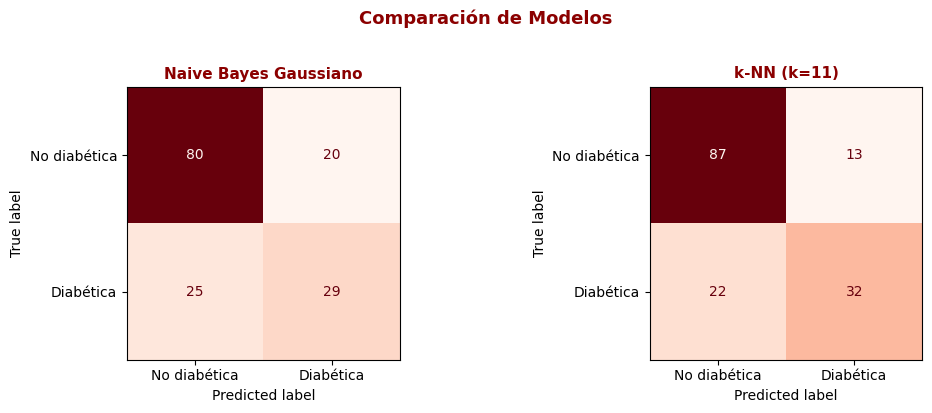

In [ ]:
labels = ['No diabética', 'Diabética']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Matriz de Confusión para Naive Bayes
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
ConfusionMatrixDisplay(
    confusion_matrix=cm_gnb,
    display_labels=labels
).plot(ax=axes[0], cmap='Reds', colorbar=False)
axes[0].set_title('Naive Bayes Gaussiano', fontsize=11, fontweight='bold', color=UPCH_RED)
# Matriz de Confusión para k-NN
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=clases
).plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title(f'k-NN (k={k_optimo})', fontsize=11, fontweight='bold', color=UPCH_RED)

fig.suptitle('Comparación de Modelos', fontsize=13, fontweight='bold', color=UPCH_RED, y=1.02)

plt.tight_layout()
plt.savefig('cm_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 7.2 — Tabla de métricas clínicas

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: calcula para ambos modelos: accuracy, precision, recall, f1
#       sobre la clase positiva (Diabética = 1)
#       imprime una tabla comparativa clara

from sklearn.metrics import precision_score, recall_score, f1_score

modelos = ['k-NN', 'Naive Bayes']
y_preds = [y_pred_knn, y_pred_gnb]

metricas = {}
for nombre, y_p in zip(modelos, y_preds):
    metricas[nombre] = {
        'Accuracy':  accuracy_score(y_test, y_p),
        'Precision': precision_score(y_test, y_p, pos_label=1),
        'Recall':    recall_score(y_test, y_p,    pos_label=1),
        'F1-score':  f1_score(y_test, y_p,        pos_label=1)
    }

print('\nTabla resumen:')
print(f'{"Métrica":<12} {modelos[0].replace(chr(10)," "):<25} {modelos[1].replace(chr(10)," "):<25}')
print('-' * 65)
for m in nombres_metricas:
    print(f'{m:<12} {metricas[modelos[0]][m]:.4f}                    {metricas[modelos[1]][m]:.4f}')


print('\n→ ¿Cuál modelo tiene mayor Recall? ¿Por qué eso importa clínicamente?')
print('\n→ El modelo con más recall es k-NN, esto importa clínicamente ya que dentro del grupo de personas verdaderamente enfermas, el modelo debe ser capaz de asertar a la mayoría ')


Tabla resumen:
Métrica      k-NN                      Naive Bayes              
-----------------------------------------------------------------
Accuracy     0.7727                    0.7078
Precision    0.7111                    0.5918
Recall       0.5926                    0.5370
F1-score     0.6465                    0.5631

→ ¿Cuál modelo tiene mayor Recall? ¿Por qué eso importa clínicamente?

→ El modelo con más recall es k-NN, esto importa clínicamente ya que dentro del grupo de personas verdaderamente enfermas, el modelo debe ser capaz de asertar a la mayoría 


### Paso 7.3 — Gráfico comparativo de métricas

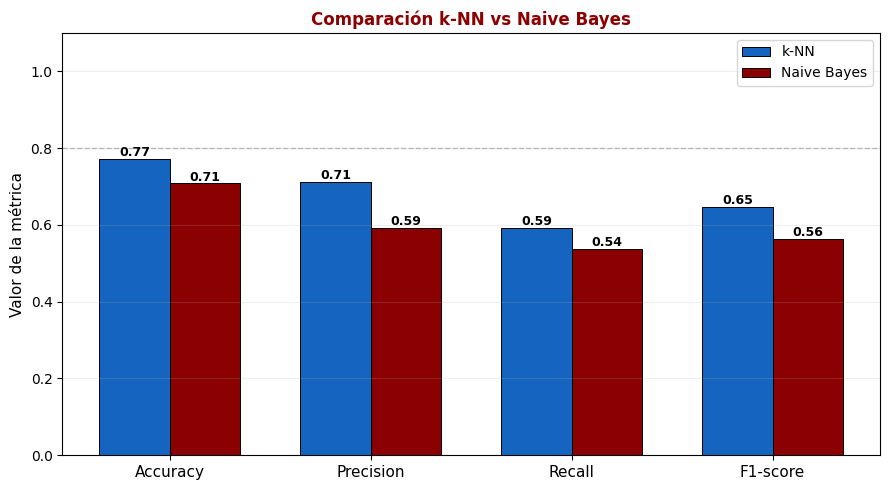

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica un bar chart comparando accuracy, precision, recall y F1
# para k-NN y Naive Bayes, con colores UPCH

nombres_metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(nombres_metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - ancho/2,
            [metricas[modelos[0]][m] for m in nombres_metricas],
            ancho, label=modelos[0], color=UPCH_BLUE, edgecolor='black', linewidth=0.7)
b2 = ax.bar(x + ancho/2,
            [metricas[modelos[1]][m] for m in nombres_metricas],
            ancho, label=modelos[1], color=UPCH_RED,  edgecolor='black', linewidth=0.7)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.007,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_title('Comparación k-NN vs Naive Bayes',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.set_xticks(x)
ax.set_xticklabels(nombres_metricas, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Referencia 0.8')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ejercicio 8 — Umbral de decisión y probabilidades posteriores

Naive Bayes entrega **probabilidades**, no solo etiquetas. En clínica podemos ajustar el umbral de decisión según el contexto:
- Tamizaje masivo → umbral bajo → maximizar recall (menos FN)
- Confirmación diagnóstica → umbral alto → maximizar precision (menos FP)

Por defecto, scikit-learn usa umbral = 0.5.

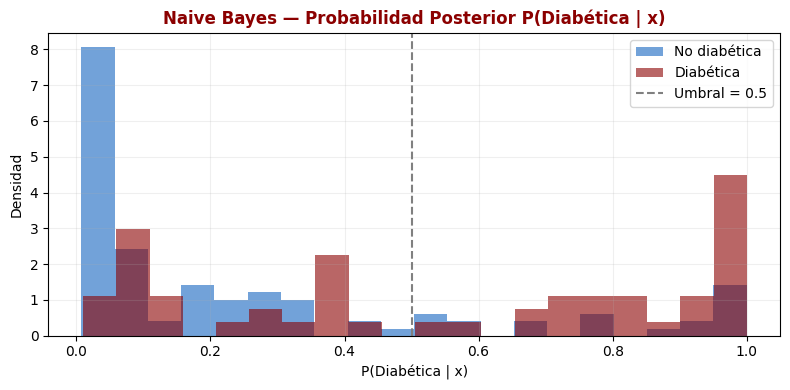

In [ ]:
proba_gnb = gnb.predict_proba(X_test_imp)[:, 1]  # P(Diabética | x)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: grafica el histograma de probabilidades P(Diabética | x)
#         diferenciando por clase real (y_test == 0 y y_test == 1)
#         con alpha=0.6, UPCH_BLUE y UPCH_RED
#         agrega una línea vertical en 0.5 (umbral por defecto)

fig, ax = plt.subplots(figsize=(8, 4))

# Histograma para la clase 0 (No diabética)
ax.hist(proba_gnb[y_test == 0], bins=20, density=True, alpha=0.6, color=UPCH_BLUE, label='No diabética')
# Histograma para la clase 1 (Diabética)
ax.hist(proba_gnb[y_test == 1], bins=20, density=True, alpha=0.6, color=UPCH_RED, label='Diabética')

# Línea vertical en 0.5 (umbral por defecto)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Umbral = 0.5')

ax.set_title('Naive Bayes — Probabilidad Posterior P(Diabética | x)', fontweight='bold', color=UPCH_RED)
ax.set_xlabel('P(Diabética | x)')
ax.set_ylabel('Densidad')
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('histograma_proba.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
proba_gnb = gnb.predict_proba(X_test_imp)[:, 1]  # P(Diabética | x)

# --- COMPLETA EL CÓDIGO ---
# TODO 2: evalúa el modelo con umbral = 0.35 (tamizaje) y umbral = 0.65 (confirmación)
#         Compara recall y precision en ambos casos vs el umbral por defecto (0.5)
#         Imprime una tabla con: umbral, precision, recall, F1

print('Evaluación del modelo Naive Bayes con diferentes umbrales:')
print(f'{"Umbral":<8} {"Precision":<12} {"Recall":<12} {"F1-score":<12} {"Accuracy":<12}')
print('-' * 60)

for umbral in [0.35, 0.50, 0.65]:
    y_pred_umbral = (proba_gnb >= umbral).astype(int)
    precision = precision_score(y_test, y_pred_umbral, pos_label=1)
    recall = recall_score(y_test, y_pred_umbral, pos_label=1)
    f1 = f1_score(y_test, y_pred_umbral, pos_label=1)
    accuracy = accuracy_score(y_test, y_pred_umbral)
    print(f'{umbral:<8.2f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {accuracy:<12.4f}')

print()
print('→ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,')
print('  qué umbral recomendarías y por qué?')

####
print('Recomendaría un umbral de 0.35. Con este se obtiene un mayor recall, lo que significa que se detecta una mayor número de pacientes verdaderamente positivos.\n Esto es crucial para atender a la mayor cantidad de pacientes enfermos posibles')
####

Evaluación del modelo Naive Bayes con diferentes umbrales:
Umbral   Precision    Recall       F1-score     Accuracy    
------------------------------------------------------------
0.35     0.6066       0.6852       0.6435       0.7338      
0.50     0.5918       0.5370       0.5631       0.7078      
0.65     0.6429       0.5000       0.5625       0.7273      

→ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,
  qué umbral recomendarías y por qué?
Recomendaría un umbral de 0.35. Con este se obtiene un mayor recall, lo que significa que se detecta una mayor número de pacientes verdaderamente positivos.
 Esto es crucial para atender a la mayor cantidad de pacientes enfermos posibles


---
## Ejercicio 9 — Impacto del Prior (reflexión bayesiana)

El Teorema de Bayes que estudiamos en Clase 1 está en el corazón de Naive Bayes. Ahora lo aplicamos directamente.

In [ ]:
# Naive Bayes con prior ajustado manualmente
# Simulamos que estamos en una población con baja prevalencia de diabetes (5%)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con priors=[0.95, 0.05]
#         (usar parámetro priors= en el constructor)
gnb_low_prev = GaussianNB(priors=[0.95, 0.05])
gnb_low_prev.fit(X_train_imp, y_train)

# TODO 2: predice y calcula recall, precision y accuracy en test
y_pred_lp = gnb_low_prev.predict(X_test_imp)

print('Comparación de priors:')
print(f'  Prior original (~35% diabetes):  Recall={recall_score(y_test, y_pred_gnb):.4f}  Precision={precision_score(y_test, y_pred_gnb):.4f} Accuracy={accuracy_score(y_test, y_pred_gnb):.4f}')
print(f'  Prior 5% diabetes:               Recall={recall_score(y_test, y_pred_lp):.4f}  Precision={precision_score(y_test, y_pred_lp):.4f} Accuracy={accuracy_score(y_test, y_pred_lp):.4f}')
print()
print('📝 Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?')
print(' Si la prevalencia es baja, el recall también disminuye. Esto se da debido a que según el modelo NB depende fuertemente del valor del prior')


Comparación de priors:
  Prior original (~35% diabetes):  Recall=0.5370  Precision=0.5918 Accuracy=0.7078
  Prior 5% diabetes:               Recall=0.2593  Precision=0.6087 Accuracy=0.6818

📝 Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?
 Si la prevalencia es baja, el recall también disminuye. Esto se da debido a que según el modelo NB depende fuertemente del valor del prior


---
## Ejercicio 10 — Análisis final e interpretación clínica

Responde las siguientes preguntas integrando los resultados obtenidos:

### 10.1 — ¿Cuál modelo elegirías y para qué escenario?

Completa la tabla:

| Escenario | Modelo recomendado | Métrica prioritaria | Justificación |
|---|---|---|---|
| Screening masivo en posta rural | Naive Bayes | Recall | Un alto recall asegura detectar al mayor número posible de pacientes con diabetes, minimizando falsos negativos. Esto es crucial en el screening para evitar el subdiagnóstico de la enfermedad, aunque implique más falsos positivos iniciales que serán confirmados posteriormente. |
| Confirmación diagnóstica en hospital | k-NN | Precision | Para la confirmación diagnóstica, es fundamental que un resultado positivo sea altamente fiable para evitar tratamientos innecesarios, ansiedad en el paciente o el uso ineficiente de recursos. |
| Sistema embebido en glucómetro portátil | Naive Bayes | F1-score | Es computacionalmente más ligero y requiere menos memoria, ideal para sistemas embebidos con recursos limitados. Un F1-score equilibrado es importante para una buena clasificación general, buscando un balance entre detectar a los enfermos y evitar falsas alarmas en un dispositivo de uso diario. |

**📝 Tu respuesta (edita esta celda)**

### 10.2 — Limitaciones del análisis

1. ¿Qué asunciones de Naive Bayes se violan en este dataset? ¿Cómo lo detectaste?
2. ¿Por qué k-NN puede ser problemático si el dataset tuviera 50,000 pacientes y 200 features?
3. ¿Qué otra métrica de evaluación sería importante reportar en el contexto clínico?

**📝 Tu respuesta (edita esta celda):**
1.  La independencia entre las variables predictoras. Se detecta en el paso 4.2, al observarse que la glucosa y la insulina tienen una correlación de 0.58, Como el valor es distinto a cero entonces las variables no son independientes; cosa que contradice la suposición fundamental de Naive Bayes
2. Debido a su alto coste computacional, sus elevados requisitos de memoria y su sensibilidad al ruido por features irrelevantes.
3. Serían importantes la Especificidad, dado que al tenerla en un valor elevado es crucial cuando los falsos positivos pueden tener consecuencias negativas significativas. También el Valor Predictivo Negativo, al ser alto es vital en escenarios donde es importante descartar la enfermedad de manera fiable evitando la necesidad de más pruebas o seguimiento en caso un paciente si se encuentre realmente sano.

In [ ]:
# Resumen ejecutivo final
print('=' * 60)
print('          RESUMEN DEL CHALLENGE 2')
print('=' * 60)
print(f'Dataset: Pima Indians Diabetes  (N={len(df)}, d=8)')
print(f'Prevalencia en test: {100*(y_test==1).mean():.1f}%')
print()
print(f'{"Modelo":<20} {"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 60)

for nombre, y_p in [(f'k-NN (k={k_optimo})', y_pred_knn), ('Naive Bayes', y_pred_gnb)]:
    print(f'{nombre:<20} '
          f'{accuracy_score(y_test, y_p):.4f}       '
          f'{recall_score(y_test, y_p):.4f}       '
          f'{precision_score(y_test, y_p):.4f}       '
          f'{f1_score(y_test, y_p):.4f}')

print()
print('Archivos generados:')
print('  distribucion_diabetes.png   eda_diabetes.png')
print('  knn_seleccion_k_diabetes.png cm_comparacion.png')
print('  comparacion_metricas.png    histograma_proba.png')

          RESUMEN DEL CHALLENGE 2
Dataset: Pima Indians Diabetes  (N=768, d=8)
Prevalencia en test: 35.1%

Modelo               Accuracy     Recall       Precision    F1
------------------------------------------------------------
k-NN (k=11)          0.7727       0.5926       0.7111       0.6465
Naive Bayes          0.7078       0.5370       0.5918       0.5631

Archivos generados:
  distribucion_diabetes.png   eda_diabetes.png
  knn_seleccion_k_diabetes.png cm_comparacion.png
  comparacion_metricas.png    histograma_proba.png
